# Polished LAS Parser and Plotting Notebook

This version tightens typing, makes plotting cells fail more gracefully, and adds clearer messages when no `.las` files are found.

## 1. Imports and notebook setup

In [1]:

# Imports
from __future__ import annotations

from pathlib import Path
import re
from typing import Any, Iterable, Mapping, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from IPython.display import display, Markdown

# Ensures figures render in the notebook
%matplotlib inline

# Display options
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Notebook setup complete.")


Notebook setup complete.


## 2. Configuration

Update `DATA_DIR` to the folder containing your LAS files. If that folder does not exist, the notebook will try a simple auto-discovery search.

In [2]:

# === Configuration ===
# Preferred folder containing .las files
DATA_DIR = Path("./data/acs")

# Optional: file pattern
FILE_GLOB = "*.las"

# Whether to search a few common locations if DATA_DIR does not exist
AUTO_DISCOVER = True
SEARCH_ROOTS = [Path("."), Path("/mnt/data")]


def discover_las_dir(preferred_dir: Path, file_glob: str = "*.las") -> Path:
    """Resolve a folder containing LAS files."""
    if preferred_dir.exists() and any(preferred_dir.rglob(file_glob)):
        return preferred_dir

    if AUTO_DISCOVER:
        for root in SEARCH_ROOTS:
            if not root.exists():
                continue
            matches = list(root.rglob(file_glob))
            if matches:
                return matches[0].parent

    return preferred_dir


DATA_DIR = discover_las_dir(DATA_DIR, FILE_GLOB)

print(f"Resolved DATA_DIR: {DATA_DIR}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")


Resolved DATA_DIR: data\acs
DATA_DIR exists: True


## 3. LAS parsing helpers

In [3]:

ASCII_MARKER = "~ASCII LOG DATA"
HEADER_KEYS = ["STRT", "STOP", "STEP", "NULL", "DATE"]


def _find_ascii_start(lines: Sequence[str]) -> int:
    """Return the index of the line containing '~ASCII LOG DATA' (case-insensitive)."""
    for i, line in enumerate(lines):
        if ASCII_MARKER in line.upper():
            return i
    raise ValueError("~ASCII LOG DATA not found in LAS file")


def _parse_null_from_header(lines: Sequence[str], default: float = -999.25) -> float:
    """Attempt to read the NULL value from header lines."""
    for line in lines:
        upper = line.upper()
        if upper.startswith("NULL."):
            rest = line.split("NULL.", 1)[1]
            match = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", rest)
            if match:
                try:
                    return float(match.group(0))
                except ValueError:
                    pass
    return default


def _parse_header_metadata(lines: Sequence[str]) -> dict[str, Any]:
    """Extract a few common LAS header values from the file header."""
    metadata: dict[str, Any] = {key: None for key in HEADER_KEYS}

    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("~"):
            continue

        for key in HEADER_KEYS:
            if stripped.upper().startswith(f"{key}."):
                rest = stripped.split(".", 1)[1]
                match = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", rest)
                if match:
                    try:
                        metadata[key] = float(match.group(0))
                    except ValueError:
                        metadata[key] = match.group(0)
                else:
                    metadata[key] = rest.strip()
                break

    if metadata["NULL"] is None:
        metadata["NULL"] = _parse_null_from_header(lines)

    return metadata


def read_las_file(filepath: Path) -> dict[str, Any]:
    """Read a simple LAS file into a dataframe plus metadata."""
    text = filepath.read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()

    ascii_start_idx = _find_ascii_start(lines)
    metadata = _parse_header_metadata(lines[:ascii_start_idx])

    data_lines = [
        line.strip()
        for line in lines[ascii_start_idx + 1 :]
        if line.strip() and not line.strip().startswith("#")
    ]

    rows: list[list[float]] = []
    for line in data_lines:
        parts = re.split(r"\s+", line.strip())
        try:
            rows.append([float(value) for value in parts])
        except ValueError:
            continue

    if not rows:
        raise ValueError(f"No numeric ASCII rows found in {filepath.name}")

    n_cols = len(rows[0])
    generic_columns = ["start_depth_m", "end_depth_m", "incline_deg", "azimuth_deg", "gamma_cps"]
    if n_cols <= len(generic_columns):
        columns = generic_columns[:n_cols]
    else:
        columns = generic_columns + [f"track_{i + 1}" for i in range(n_cols - len(generic_columns))]

    df = pd.DataFrame(rows, columns=columns)

    null_value = metadata.get("NULL", -999.25)
    df = df.replace(null_value, np.nan)

    if {"start_depth_m", "end_depth_m"}.issubset(df.columns):
        df["depth_mid_m"] = (df["start_depth_m"] + df["end_depth_m"]) / 2.0
    elif "start_depth_m" in df.columns:
        df["depth_mid_m"] = df["start_depth_m"]
    else:
        df["depth_mid_m"] = np.arange(len(df), dtype=float)

    return {
        "hole_id": filepath.stem,
        "filepath": filepath,
        "metadata": metadata,
        "df": df,
    }


def load_all_las(data_dir: Path, file_glob: str = "*.las") -> dict[str, dict[str, Any]]:
    """Load all LAS files from a directory tree."""
    parsed: dict[str, dict[str, Any]] = {}

    if not data_dir.exists():
        print(f"Directory does not exist: {data_dir}")
        return parsed

    files = sorted(data_dir.rglob(file_glob))
    if not files:
        print(f"No LAS files found under: {data_dir}")
        return parsed

    for filepath in files:
        try:
            entry = read_las_file(filepath)
            parsed[filepath.stem] = entry
        except Exception as exc:
            print(f"Skipping {filepath.name}: {exc}")

    return parsed


## 4. Load files

In [4]:

parsed = load_all_las(DATA_DIR, FILE_GLOB)

print(f"Parsed files: {len(parsed)}")
if parsed:
    display(pd.DataFrame({
        "hole_id": list(parsed.keys()),
        "file": [str(entry["filepath"]) for entry in parsed.values()],
        "rows": [len(entry["df"]) for entry in parsed.values()],
    }))
else:
    display(Markdown(
        "**No LAS files were found.**\n\n"
        "Update `DATA_DIR` in the configuration cell so it points to your LAS folder, "
        "then rerun from the configuration cell downward."
    ))


Parsed files: 31


,hole_id,file,rows
0,B10_GV_U,data\acs\B10_GV_U.las,1363
1,B10_GV_U_10,data\acs\B10_GV_U_10.las,1398
2,B10_GV_U_15,data\acs\B10_GV_U_15.las,1369
3,B10_GV_U_MAX,data\acs\B10_GV_U_MAX.las,1358
4,B11_GV_U,data\acs\B11_GV_U.las,1063
...,...,...,...
26,B5_GV_U,data\acs\B5_GV_U.las,1562
27,B6_GV_U,data\acs\B6_GV_U.las,1563
28,B7_GV_U,data\acs\B7_GV_U.las,1665
29,B8_GV_U,data\acs\B8_GV_U.las,1596


## 5. Quick metadata and data preview

In [5]:

if parsed:
    first_hole_id = next(iter(parsed.keys()))
    print(f"Preview hole: {first_hole_id}")
    display(pd.DataFrame([parsed[first_hole_id]["metadata"]]))
else:
    print("No preview available because no LAS files were loaded.")


Preview hole: B10_GV_U


,STRT,STOP,STEP,NULL,DATE
0,14.0,0.38,-0.01,-999.25,2025.0


In [6]:

if parsed:
    first_hole_id = next(iter(parsed.keys()))
    display(parsed[first_hole_id]["df"].head(12))
else:
    print("No dataframe preview available because no LAS files were loaded.")


,start_depth_m,end_depth_m,incline_deg,azimuth_deg,gamma_cps,depth_mid_m
0,14.00,NaN,NaN,NaN,NaN,NaN
1,13.99,13.99910,NaN,NaN,NaN,13.994550
2,13.98,13.98916,NaN,NaN,NaN,13.984580
3,13.97,13.97833,NaN,NaN,NaN,13.974165
4,13.96,13.96840,NaN,NaN,NaN,13.964200
5,13.95,13.95756,6.10208,92.56458,NaN,13.953780
6,13.94,13.94673,6.10000,92.50000,NaN,13.943365
7,13.93,13.93589,6.10000,92.65000,NaN,13.932945
8,13.92,13.92506,6.10000,92.80000,NaN,13.922530
9,13.91,13.91422,6.10000,93.05000,NaN,13.912110


## 6. Plot helpers

In [7]:

DEFAULT_TRACKS = ["incline_deg", "azimuth_deg", "gamma_cps"]


def available_tracks(
    df: pd.DataFrame,
    depth_col: str = "depth_mid_m",
    exclude: Optional[Sequence[str]] = None,
) -> list[str]:
    """Return numeric tracks that are suitable for plotting."""
    exclude_set = set(exclude or []) | {depth_col, "start_depth_m", "end_depth_m"}
    tracks: list[str] = []
    for column in df.columns:
        if column in exclude_set:
            continue
        if pd.api.types.is_numeric_dtype(df[column]):
            tracks.append(column)
    return tracks


def summarise_hole(parsed_entry: Mapping[str, Any], hole_id: Optional[str] = None) -> pd.DataFrame:
    """Create a compact summary table for one parsed hole."""
    df = parsed_entry["df"]
    metadata = parsed_entry.get("metadata", {})
    resolved_hole_id = hole_id or parsed_entry.get("hole_id") or "unknown"

    summary = {
        "hole_id": resolved_hole_id,
        "rows": len(df),
        "depth_from_m": float(df["start_depth_m"].min()) if "start_depth_m" in df.columns else np.nan,
        "depth_to_m": float(df["end_depth_m"].max()) if "end_depth_m" in df.columns else np.nan,
        "sample_interval_m": (
            float((df["end_depth_m"] - df["start_depth_m"]).median())
            if {"start_depth_m", "end_depth_m"}.issubset(df.columns)
            else np.nan
        ),
        "null_value": metadata.get("NULL"),
        "header_start": metadata.get("STRT"),
        "header_stop": metadata.get("STOP"),
        "header_step": metadata.get("STEP"),
        "date": metadata.get("DATE"),
    }

    return pd.DataFrame([summary])


def _clean_track_series(df: pd.DataFrame, column: str, depth_col: str) -> pd.DataFrame:
    temp = df[[depth_col, column]].copy()
    temp = temp.replace([np.inf, -np.inf], np.nan).dropna()
    return temp.sort_values(depth_col)


def _padded_limits(series: pd.Series, pad_frac: float = 0.08) -> Optional[tuple[float, float]]:
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        return None
    lower = float(values.min())
    upper = float(values.max())
    if lower == upper:
        delta = abs(lower) * 0.1 if lower != 0 else 1.0
        return lower - delta, upper + delta
    padding = (upper - lower) * pad_frac
    return lower - padding, upper + padding


def plot_tracks(
    df: pd.DataFrame,
    tracks: Optional[Sequence[str]] = None,
    depth_col: str = "depth_mid_m",
    title: Optional[str] = None,
    figsize: tuple[float, float] = (14, 9),
    fill_tracks: Optional[Sequence[str]] = None,
    annotate_stats: bool = True,
    depth_grid_major: float = 10.0,
    depth_grid_minor: float = 2.0,
) -> tuple[Figure, list[Axes]]:
    """Plot selected tracks vs depth as polished side-by-side panels."""
    if depth_col not in df.columns:
        raise KeyError(f"Depth column '{depth_col}' not found in dataframe.")

    if tracks is None:
        requested = [column for column in DEFAULT_TRACKS if column in df.columns]
        resolved_tracks = requested or available_tracks(df, depth_col=depth_col)
    else:
        resolved_tracks = [column for column in tracks if column in df.columns]

    if not resolved_tracks:
        raise ValueError("No numeric tracks available to plot.")

    fill_track_set = set(fill_tracks or ["gamma_cps"])
    n_tracks = len(resolved_tracks)

    fig, axes_array = plt.subplots(
        1,
        n_tracks,
        figsize=figsize,
        sharey=True,
        gridspec_kw={"wspace": 0.08},
    )
    if n_tracks == 1:
        axes_list = [axes_array]
    else:
        axes_list = list(axes_array)

    depth = pd.to_numeric(df[depth_col], errors="coerce")
    finite_depth = depth.replace([np.inf, -np.inf], np.nan).dropna()
    depth_min = float(finite_depth.min()) if not finite_depth.empty else 0.0
    depth_max = float(finite_depth.max()) if not finite_depth.empty else 1.0

    cmap = plt.get_cmap("tab10")

    for i, (ax, column) in enumerate(zip(axes_list, resolved_tracks)):
        temp = _clean_track_series(df, column, depth_col)
        color = cmap(i % 10)

        if temp.empty:
            ax.text(0.5, 0.5, f"No valid data:\n{column}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        x_values = temp[column].to_numpy()
        y_values = temp[depth_col].to_numpy()

        ax.plot(x_values, y_values, lw=1.6, color=color, solid_capstyle="round")

        if column in fill_track_set:
            baseline = float(np.nanmin(x_values))
            ax.fill_betweenx(y_values, baseline, x_values, color=color, alpha=0.20)

        limits = _padded_limits(temp[column])
        if limits is not None:
            ax.set_xlim(*limits)

        if annotate_stats:
            series = pd.to_numeric(temp[column], errors="coerce")
            stats_text = f"min {series.min():.2f}\nmean {series.mean():.2f}\nmax {series.max():.2f}"
            ax.set_title(f"{column}\n{stats_text}", fontsize=10, pad=12)
        else:
            ax.set_title(column, fontsize=10, pad=12)

        ax.set_xlabel(column, fontsize=10)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=9)

        ax.set_facecolor("#fafafa")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_alpha(0.25)
        ax.spines["bottom"].set_alpha(0.25)

        ax.grid(True, axis="x", which="major", linestyle="--", alpha=0.35)
        ax.grid(True, axis="x", which="minor", linestyle=":", alpha=0.18)
        ax.grid(True, axis="y", which="major", linestyle="--", alpha=0.18)

    axes_list[0].set_ylabel("Depth (m)", fontsize=11)
    axes_list[0].set_ylim(depth_max, depth_min)
    axes_list[0].yaxis.set_major_locator(MultipleLocator(depth_grid_major))
    axes_list[0].yaxis.set_minor_locator(MultipleLocator(depth_grid_minor))
    axes_list[0].grid(True, axis="y", which="major", linestyle="--", alpha=0.22)
    axes_list[0].grid(True, axis="y", which="minor", linestyle=":", alpha=0.12)

    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold", y=0.995)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig, axes_list


def plot_hole(
    parsed_entry: Mapping[str, Any],
    hole_id: Optional[str] = None,
    tracks: Optional[Sequence[str]] = None,
    **kwargs: Any,
) -> tuple[Figure, list[Axes]]:
    """Convenience wrapper to plot one parsed hole."""
    df = parsed_entry["df"]
    metadata = parsed_entry.get("metadata", {})
    resolved_hole_id = hole_id or parsed_entry.get("hole_id") or ""

    title = resolved_hole_id
    if metadata.get("STRT") is not None or metadata.get("STOP") is not None:
        title = f"{resolved_hole_id}  |  {metadata.get('STRT', '?')} m to {metadata.get('STOP', '?')} m"

    return plot_tracks(df, tracks=tracks, title=title, **kwargs)


def plot_track_distributions(
    df: pd.DataFrame,
    tracks: Optional[Sequence[str]] = None,
    bins: int = 30,
    figsize: tuple[float, float] = (14, 3.8),
) -> tuple[Figure, list[Axes]]:
    """Plot histograms for selected tracks."""
    resolved_tracks = list(tracks) if tracks is not None else available_tracks(df)

    if not resolved_tracks:
        raise ValueError("No numeric tracks available to plot.")

    fig, axes_array = plt.subplots(1, len(resolved_tracks), figsize=figsize, squeeze=False)
    axes_list = list(axes_array.ravel())
    cmap = plt.get_cmap("tab10")

    for i, (ax, column) in enumerate(zip(axes_list, resolved_tracks)):
        values = pd.to_numeric(df[column], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            ax.text(0.5, 0.5, f"No valid data:\n{column}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.hist(values, bins=bins, color=cmap(i % 10), alpha=0.75, edgecolor="white")
        ax.set_title(column, fontsize=10)
        ax.set_xlabel(column, fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(True, axis="y", linestyle="--", alpha=0.25)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    fig.tight_layout()
    return fig, axes_list


def plot_correlation_heatmap(
    df: pd.DataFrame,
    tracks: Optional[Sequence[str]] = None,
    figsize: tuple[float, float] = (6, 5),
) -> tuple[Figure, Axes]:
    """Plot a correlation heatmap for numeric tracks."""
    resolved_tracks = list(tracks) if tracks is not None else available_tracks(df)
    if not resolved_tracks:
        raise ValueError("No numeric tracks available to plot.")

    numeric_df = df[resolved_tracks].apply(pd.to_numeric, errors="coerce")
    corr = numeric_df.corr()

    fig, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(corr, aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            value = corr.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

    ax.set_title("Track correlation matrix", fontsize=11, pad=10)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
    fig.tight_layout()
    return fig, ax


def plot_hole_dashboard(
    parsed_entry: Mapping[str, Any],
    hole_id: Optional[str] = None,
    tracks: Optional[Sequence[str]] = None,
    depth_col: str = "depth_mid_m",
    figsize: tuple[float, float] = (16, 10),
) -> Figure:
    """Create a compact QC dashboard for one hole."""
    df = parsed_entry["df"]
    metadata = parsed_entry.get("metadata", {})
    resolved_hole_id = hole_id or parsed_entry.get("hole_id") or "unknown"

    if tracks is None:
        resolved_tracks = [column for column in DEFAULT_TRACKS if column in df.columns]
        if not resolved_tracks:
            resolved_tracks = available_tracks(df, depth_col=depth_col)[:3]
    else:
        resolved_tracks = [column for column in tracks if column in df.columns]

    if not resolved_tracks:
        raise ValueError("No numeric tracks available for dashboard plotting.")

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(2, max(3, len(resolved_tracks)), height_ratios=[3.2, 1.4])

    cmap = plt.get_cmap("tab10")
    depth = pd.to_numeric(df[depth_col], errors="coerce")
    finite_depth = depth.replace([np.inf, -np.inf], np.nan).dropna()
    depth_min = float(finite_depth.min()) if not finite_depth.empty else 0.0
    depth_max = float(finite_depth.max()) if not finite_depth.empty else 1.0

    for i, column in enumerate(resolved_tracks):
        ax = fig.add_subplot(gs[0, i])
        temp = _clean_track_series(df, column, depth_col)
        color = cmap(i % 10)

        if temp.empty:
            ax.text(0.5, 0.5, f"No valid data:\n{column}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        x_values = temp[column].to_numpy()
        y_values = temp[depth_col].to_numpy()

        ax.plot(x_values, y_values, lw=1.6, color=color)
        if column == "gamma_cps":
            ax.fill_betweenx(y_values, float(np.nanmin(x_values)), x_values, color=color, alpha=0.18)

        limits = _padded_limits(temp[column])
        if limits is not None:
            ax.set_xlim(*limits)

        ax.set_title(column, fontsize=10)
        ax.set_xlabel(column, fontsize=9)
        if i == 0:
            ax.set_ylabel("Depth (m)", fontsize=10)
            ax.yaxis.set_major_locator(MultipleLocator(10))
            ax.yaxis.set_minor_locator(MultipleLocator(2))
        else:
            ax.set_yticklabels([])
        ax.set_ylim(depth_max, depth_min)
        ax.grid(True, linestyle="--", alpha=0.25)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    ax_info = fig.add_subplot(gs[1, :2])
    ax_info.axis("off")
    summary = summarise_hole(parsed_entry, hole_id=resolved_hole_id).iloc[0].to_dict()

    info_lines = [
        f"Hole ID: {summary['hole_id']}",
        f"Rows: {int(summary['rows'])}",
        f"Depth interval: {summary['depth_from_m']:.2f} m to {summary['depth_to_m']:.2f} m",
        f"Median sample length: {summary['sample_interval_m']:.2f} m",
        f"Header STEP: {summary['header_step']}",
        f"Date: {summary['date']}",
    ]
    ax_info.text(
        0.0,
        1.0,
        "\n".join(info_lines),
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f7f7f7", edgecolor="#dddddd"),
    )

    hist_track = resolved_tracks[0]
    ax_hist = fig.add_subplot(gs[1, 2:])
    values = pd.to_numeric(df[hist_track], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if not values.empty:
        ax_hist.hist(values, bins=30, alpha=0.8, edgecolor="white")
        ax_hist.set_title(f"{hist_track} distribution", fontsize=10)
        ax_hist.set_xlabel(hist_track, fontsize=9)
        ax_hist.set_ylabel("Count", fontsize=9)
        ax_hist.grid(True, axis="y", linestyle="--", alpha=0.25)
        for spine in ["top", "right"]:
            ax_hist.spines[spine].set_visible(False)
    else:
        ax_hist.text(0.5, 0.5, f"No valid data for {hist_track}", ha="center", va="center", transform=ax_hist.transAxes)
        ax_hist.set_axis_off()

    meta_bits = [f"{key}={value}" for key, value in metadata.items() if value not in (None, "", "nan")]
    subtitle = "  |  ".join(meta_bits[:4])
    fig.suptitle(f"{resolved_hole_id} — hole QC dashboard", fontsize=14, fontweight="bold")
    if subtitle:
        fig.text(0.5, 0.965, subtitle, ha="center", va="top", fontsize=9, color="dimgray")

    return fig


## 7. Summary and polished plots

,hole_id,rows,depth_from_m,depth_to_m,sample_interval_m,null_value,header_start,header_stop,header_step,date
0,B10_GV_U,1363,0.38,13.9991,0.006,-999.25,14.0,0.38,-0.01,2025.0


C:\Users\expg\AppData\Local\Temp\ipykernel_28052\1142669030.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


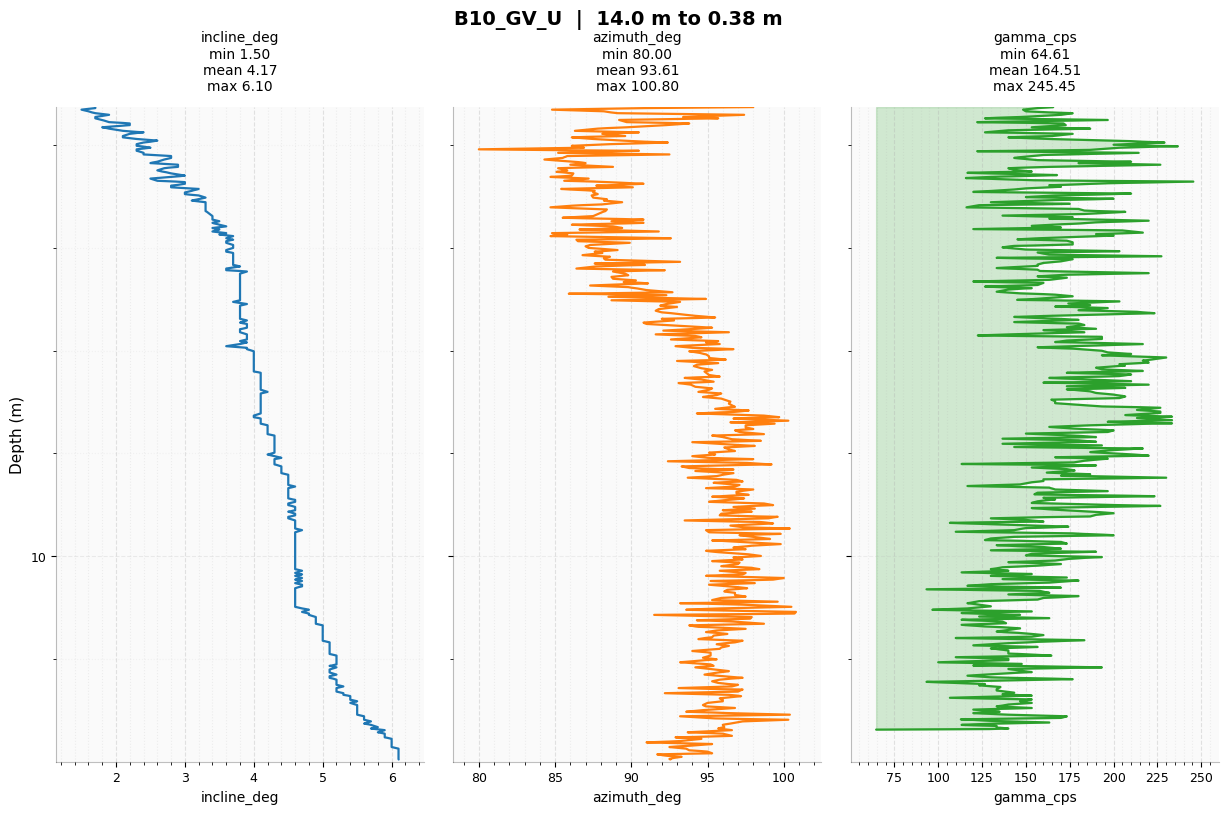

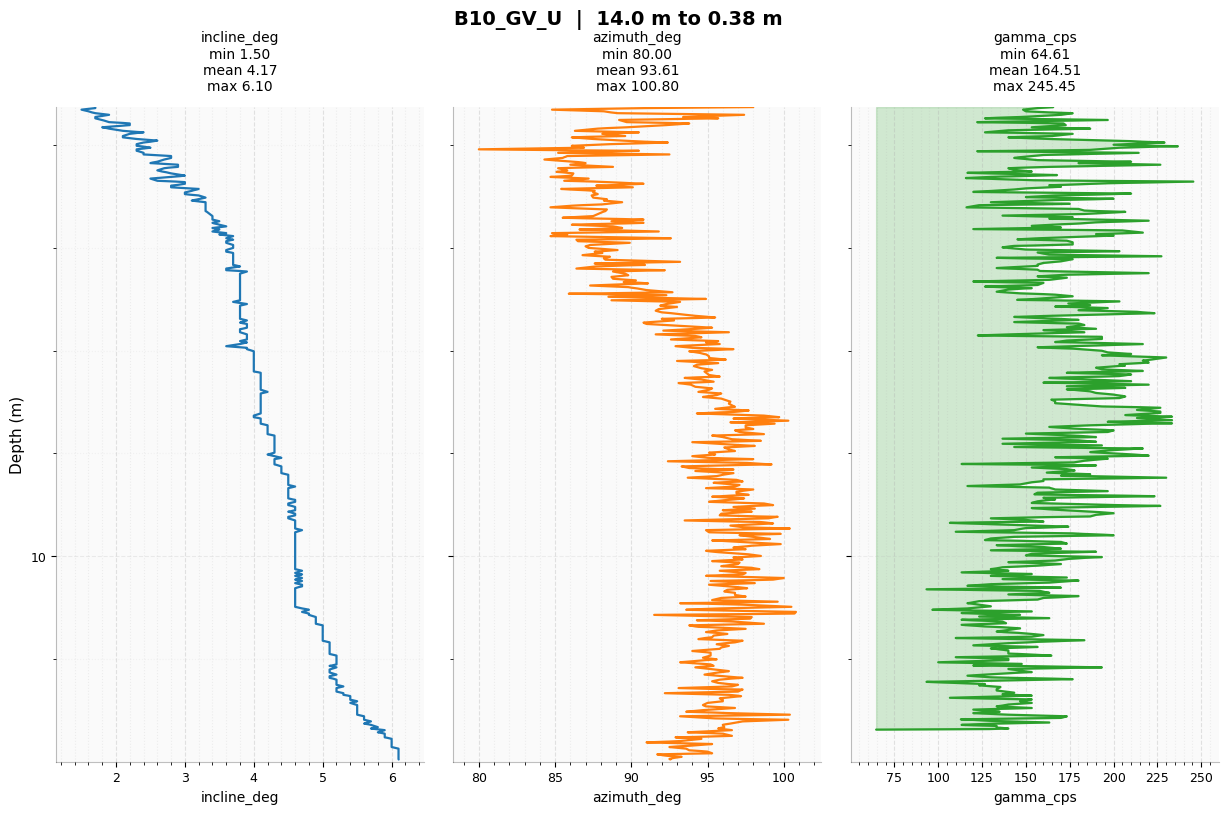

In [8]:

if parsed:
    first_hole_id = next(iter(parsed.keys()))
    display(summarise_hole(parsed[first_hole_id], hole_id=first_hole_id))
    fig, _ = plot_hole(
        parsed[first_hole_id],
        hole_id=first_hole_id,
        tracks=["incline_deg", "azimuth_deg", "gamma_cps"],
        figsize=(15, 8.5),
    )
    display(fig)
    plt.show()
else:
    print("No plots available because no LAS files were loaded.")


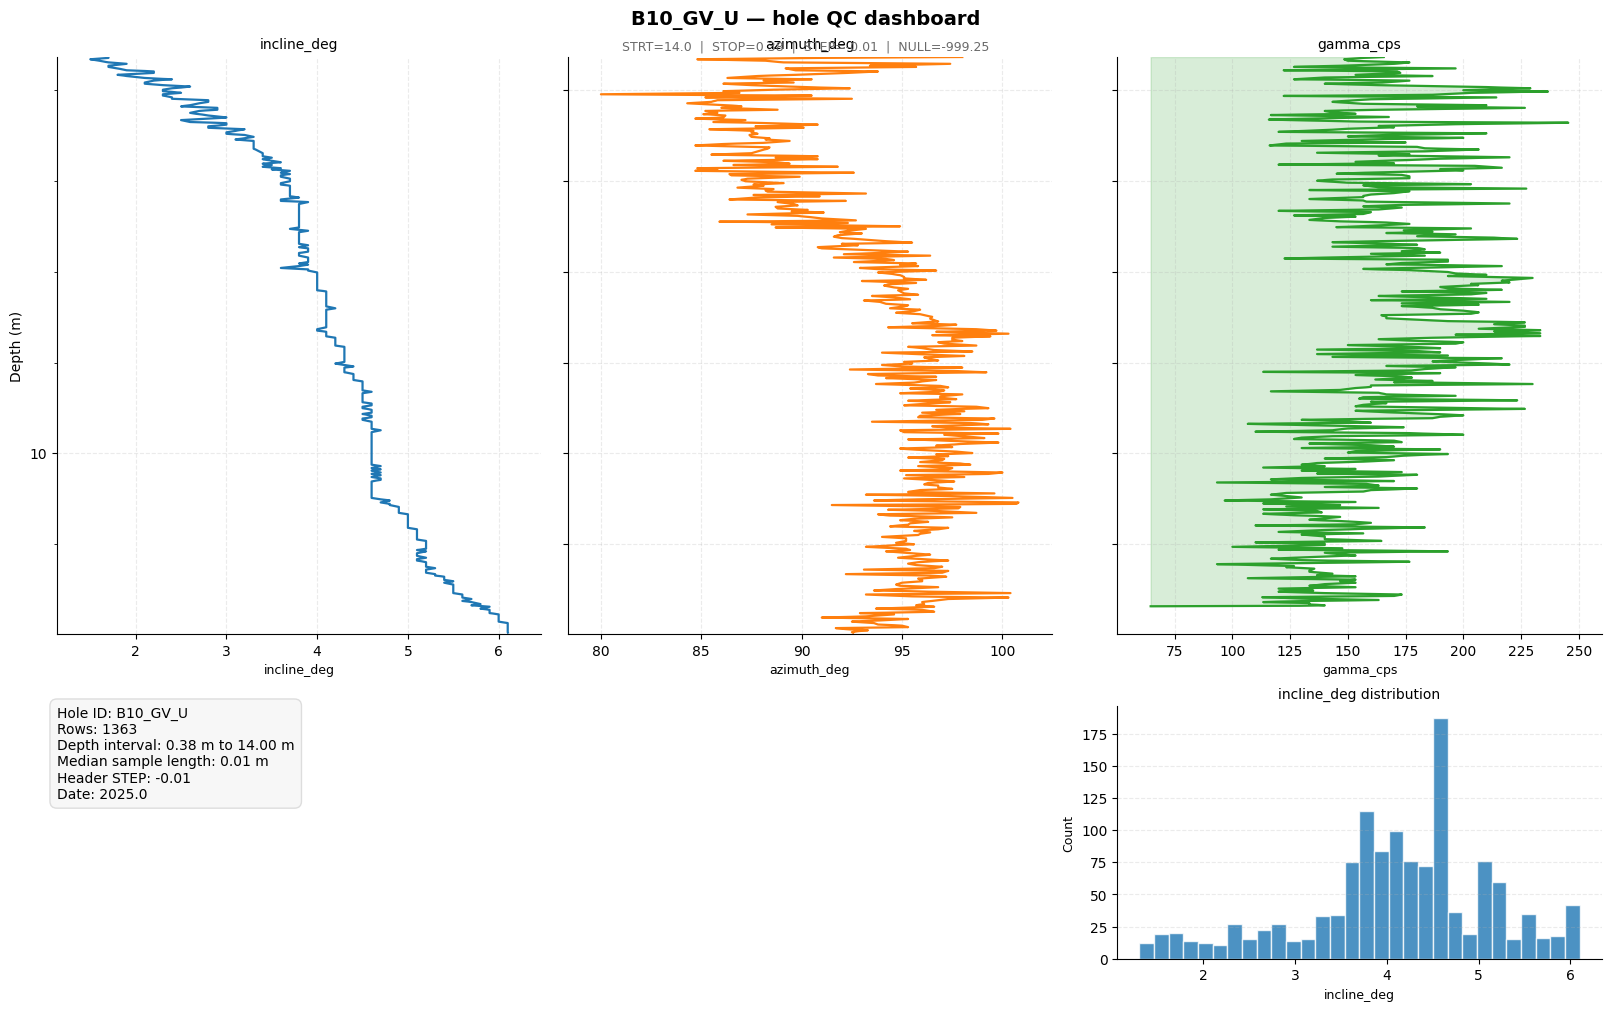

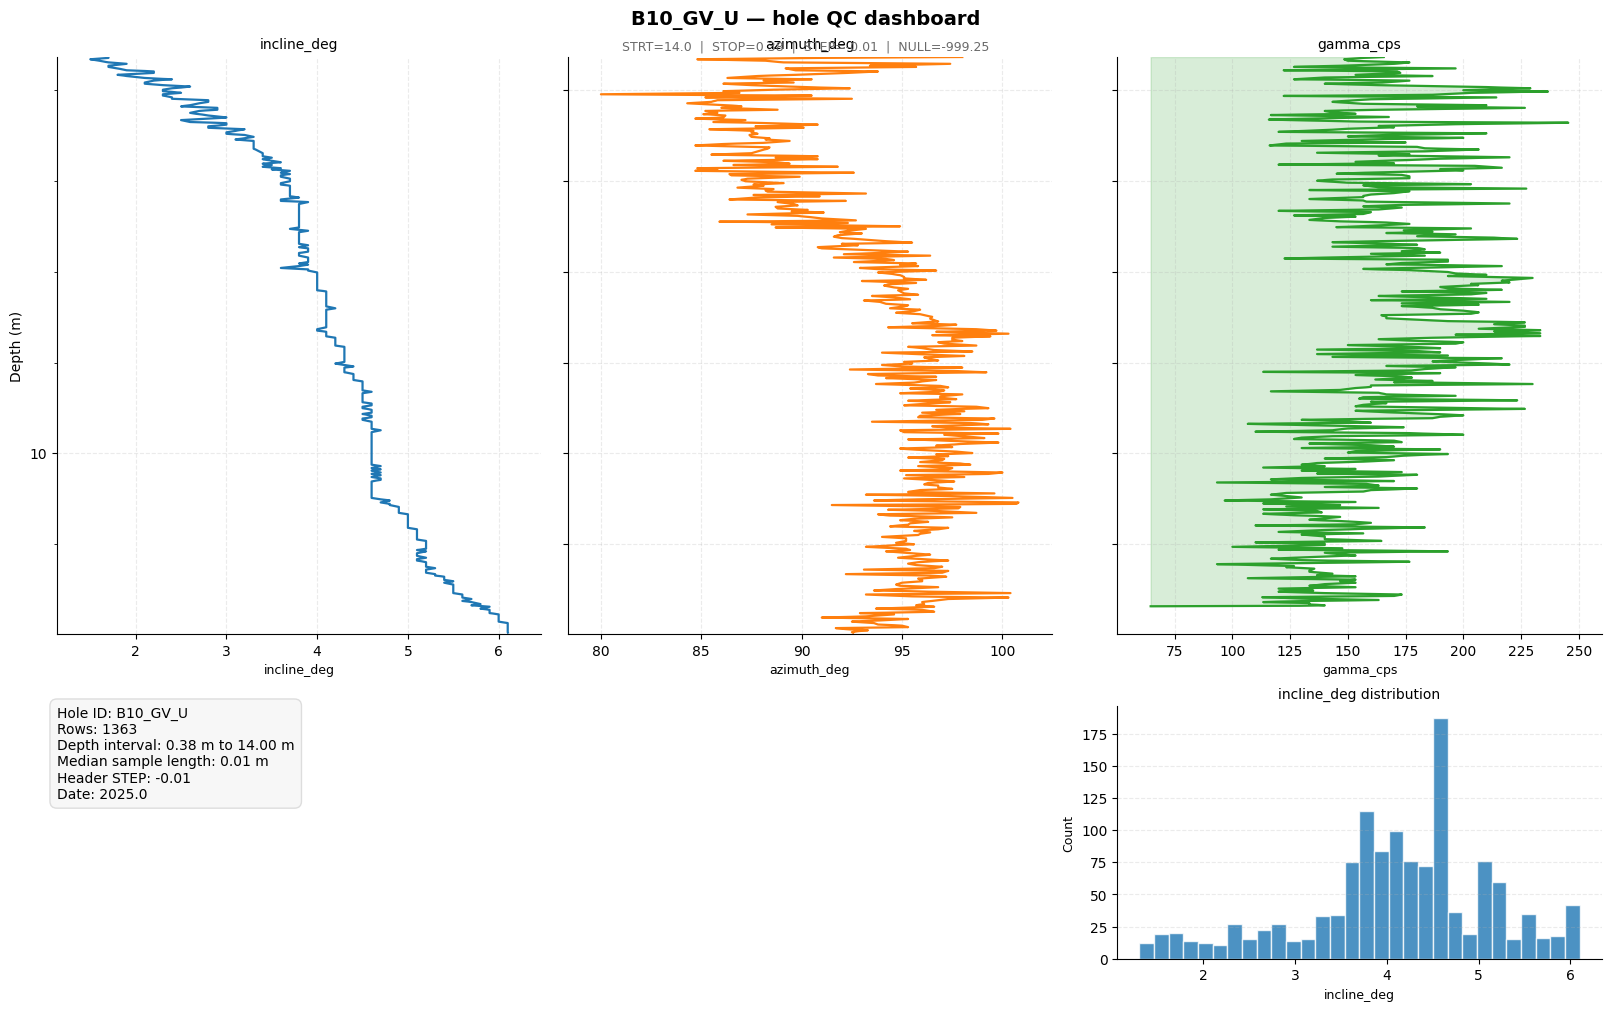

In [9]:

if parsed:
    first_hole_id = next(iter(parsed.keys()))
    fig = plot_hole_dashboard(parsed[first_hole_id], hole_id=first_hole_id)
    display(fig)
    plt.show()
else:
    print("No dashboard available because no LAS files were loaded.")


## 8. Distributions and correlation

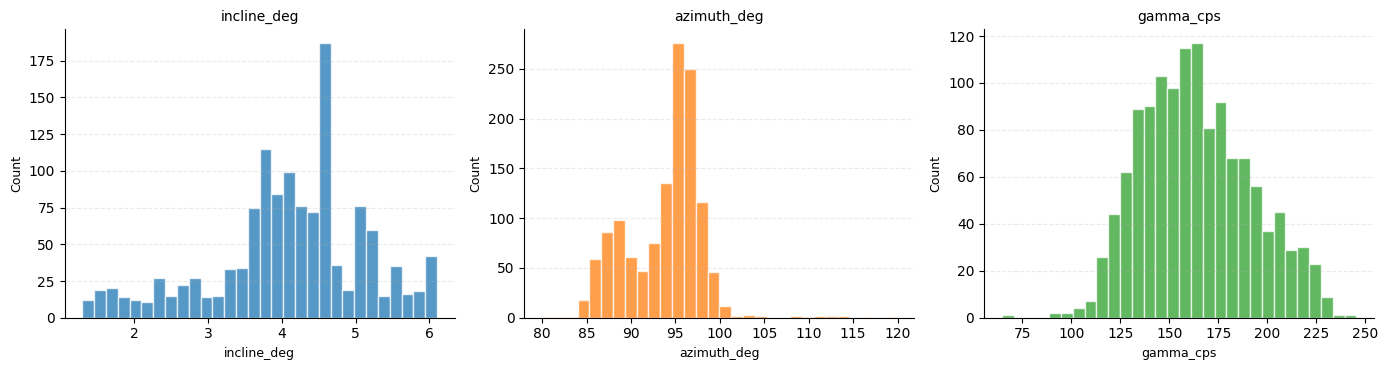

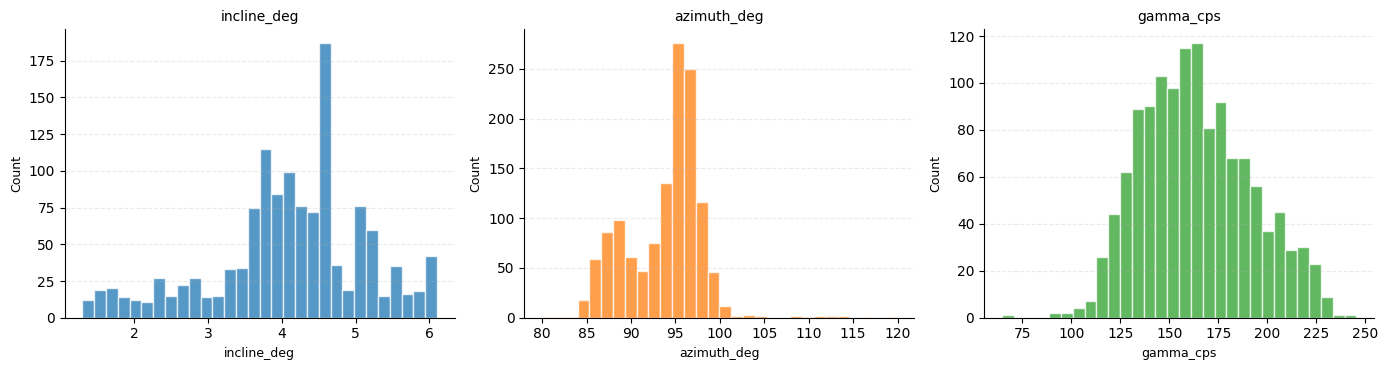

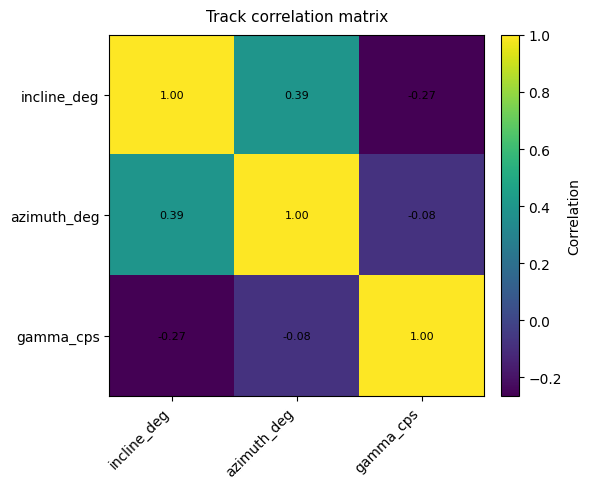

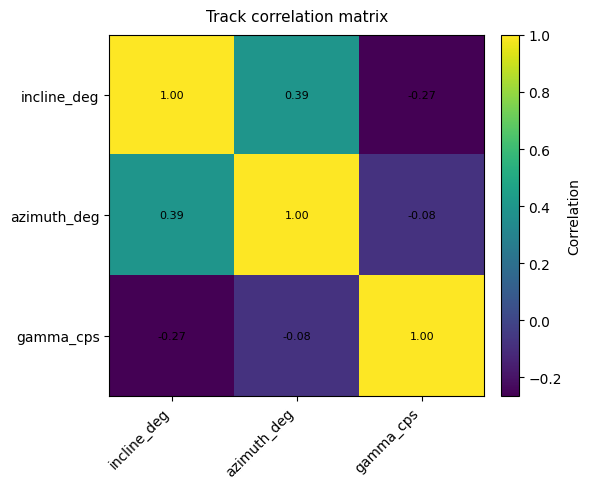

In [10]:

if parsed:
    first_hole_id = next(iter(parsed.keys()))
    df = parsed[first_hole_id]["df"]

    tracks = [column for column in ["incline_deg", "azimuth_deg", "gamma_cps"] if column in df.columns]
    if not tracks:
        tracks = available_tracks(df)[:3]

    fig, _ = plot_track_distributions(df, tracks=tracks)
    display(fig)
    plt.show()

    fig, _ = plot_correlation_heatmap(df, tracks=tracks)
    display(fig)
    plt.show()
else:
    print("No distribution or correlation plots available because no LAS files were loaded.")


## 9. Combined tables

In [11]:

if parsed:
    frames: list[pd.DataFrame] = []
    hole_summaries: list[pd.DataFrame] = []

    for hole_id, entry in parsed.items():
        df = entry["df"].copy()
        df["hole_id"] = hole_id
        frames.append(df)
        hole_summaries.append(summarise_hole(entry, hole_id=hole_id))

    combined = pd.concat(frames, ignore_index=True)
    summary_table = pd.concat(hole_summaries, ignore_index=True)

    print(f"Combined rows: {len(combined)}")
    display(summary_table.head())
    display(combined.head())

    # Uncomment to export
    # combined.to_csv("combined_las_logs.csv", index=False)
    # summary_table.to_csv("combined_las_summary.csv", index=False)
else:
    print("No combined tables available because no LAS files were loaded.")


Combined rows: 45767


c:\GitHubRepositories\mining_sim\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,hole_id,rows,depth_from_m,depth_to_m,sample_interval_m,null_value,header_start,header_stop,header_step,date
0,B10_GV_U,1363,0.38,13.99910,0.00600,-999.25,14.0,0.38,-0.01,2025.0
1,B10_GV_U_10,1398,0.03,13.99729,0.01208,-999.25,14.0,0.03,-0.01,2025.0
2,B10_GV_U_15,1369,0.32,13.99594,0.02022,-999.25,14.0,0.32,-0.01,2025.0
3,B10_GV_U_MAX,1358,0.43,13.99097,0.03743,-999.25,14.0,0.43,-0.01,2025.0
4,B11_GV_U,1063,0.38,10.99413,0.00534,-999.25,11.0,0.38,-0.01,2025.0


,start_depth_m,end_depth_m,incline_deg,azimuth_deg,gamma_cps,depth_mid_m,hole_id
0,14.00,NaN,NaN,NaN,NaN,NaN,B10_GV_U
1,13.99,13.99910,NaN,NaN,NaN,13.994550,B10_GV_U
2,13.98,13.98916,NaN,NaN,NaN,13.984580,B10_GV_U
3,13.97,13.97833,NaN,NaN,NaN,13.974165,B10_GV_U
4,13.96,13.96840,NaN,NaN,NaN,13.964200,B10_GV_U
